# Phase 3: Association Rule Mining

This phase mines readable co-occurrence patterns from
`features_business.csv` and the Phase 2 segment labels. Continuous
amounts and ratios become named analytical bins; absent repayment or
score history remains explicitly unavailable rather than “clean.”
Apriori, FP-Growth, and ECLAT enumerate the same compact global
search space as an implementation check. Segment-context FP-Growth
keeps a separate denominator and removes the constant cluster item.

Final rules must have one consequent, at most two antecedents, a
behavior/history signal, lift at least 1.2, confidence at least 0.35,
and low redundancy. Rules made only from income, credit, leverage,
and burden are rejected as algebraic identities. Algorithm agreement
confirms enumeration consistency; it does not make a rule causal or
operationally valid.


## 1. Setup and load

In [1]:
import time, pickle, random
from pathlib import Path
from collections import defaultdict
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase3_association'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_business.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = None
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.35
MIN_LIFT = 1.20
MAX_LEN = 3                 # one or two antecedents + one consequent
JACCARD_REDUNDANCY = 0.65

def canonical_rule(antecedents, consequents):
    left = ', '.join(sorted(map(str, antecedents)))
    right = ', '.join(sorted(map(str, consequents)))
    return f'{{{left}}} -> {{{right}}}'

print('Loading business-readable features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
label_view = labels.drop(columns=[c for c in ['SK_ID_CURR'] if c in labels.columns])
df_all = pd.merge(features, label_view, on='ROW_ID', how='inner', validate='one_to_one')
assert len(df_all) == len(features)
cluster_names_df = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print(f'  business features: {features.shape}; merged: {df_all.shape}')


Loading business-readable features ...


  business features: (356255, 64); merged: (356255, 68)


## 2. Business-readable transactions

Quantiles are used for anonymized amount/score ranking where no
currency policy threshold exists. Affordability, utilization, and
delinquency use interpretable analytical cut points. `INST_COUNT`,
card months, bureau count, and score missingness separate no observed
history from clean or weak observed history. Age and gender are absent
from the vocabulary. Each item is also mapped to a semantic family so
deterministic financial identities can be audited and rejected.


In [2]:
# Every item belongs to one semantic family.  History absence is kept
# separate from clean observed repayment, and unavailable external scores
# remain unavailable rather than inheriting an imputed score label.
discretized = {}
discretized['income'] = pd.qcut(
    df_all['AMT_INCOME_TOTAL'], 4,
    labels=['income_q1', 'income_q2', 'income_q3', 'income_q4'], duplicates='drop')
discretized['credit_size'] = pd.qcut(
    df_all['AMT_CREDIT'], 3,
    labels=['credit_small', 'credit_medium', 'credit_large'], duplicates='drop')
discretized['leverage'] = pd.cut(
    df_all['CREDIT_TO_INCOME'], [-np.inf, 3, 6, np.inf],
    labels=['leverage_under_3x', 'leverage_3_to_6x', 'leverage_over_6x'])
discretized['burden'] = pd.cut(
    df_all['ANNUITY_TO_INCOME'], [-np.inf, .20, .35, np.inf],
    labels=['burden_under_20pct', 'burden_20_to_35pct', 'burden_over_35pct'])

observed_scores = pd.DataFrame(index=df_all.index)
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    source_col = f'SOURCE_{col}' if f'SOURCE_{col}' in df_all.columns else col
    values = df_all[source_col].copy()
    flag_col = f'FLAG_{col}_MISSING'
    if flag_col in df_all.columns:
        values = values.mask(df_all[flag_col].eq(1))
    observed_scores[col] = values
ext_mean = observed_scores.mean(axis=1, skipna=True)
external_score = pd.Series('external_score_unavailable', index=df_all.index, dtype=object)
valid_ext = ext_mean.notna()
external_score.loc[valid_ext] = pd.qcut(
    ext_mean.loc[valid_ext], 3,
    labels=['external_score_weak', 'external_score_middle', 'external_score_strong'],
    duplicates='drop').astype(str)
discretized['external_score'] = external_score

inst_count = df_all['INST_COUNT'].fillna(0)
serious_late = (df_all['INST_DPD_MAX'].fillna(0) > 30) | (df_all['INST_SEVERE_LATE_RATIO'].fillna(0) > 0)
any_late = df_all['INST_LATE_RATIO'].fillna(0) > 0
discretized['repayment_history'] = pd.Categorical(np.select(
    [inst_count.le(0), serious_late, any_late],
    ['repayment_not_observed', 'repayment_serious_late', 'repayment_some_late'],
    default='repayment_clean_observed'))

card_months = df_all['CC_MONTHS_COUNT'].fillna(0)
util = df_all['CC_UTILIZATION_MEAN'].fillna(0)
discretized['card_use'] = pd.Categorical(np.select(
    [card_months.le(0), util.ge(.80)],
    ['card_history_not_observed', 'card_utilisation_high'],
    default='card_utilisation_moderate'))

bureau_count = df_all['BUREAU_COUNT'].fillna(0)
discretized['credit_file'] = pd.Categorical(np.select(
    [bureau_count.le(0), bureau_count.le(2), bureau_count.ge(8)],
    ['credit_file_none', 'credit_file_thin', 'credit_file_deep'],
    default='credit_file_established'))
bureau_debt = df_all['BUREAU_DEBT_TO_CREDIT_RATIO'].fillna(0)
discretized['bureau_debt'] = pd.Categorical(np.select(
    [bureau_count.le(0), bureau_debt.ge(.80), bureau_debt.ge(.30)],
    ['bureau_debt_not_observed', 'bureau_debt_high', 'bureau_debt_moderate'],
    default='bureau_debt_low'))

prev_count = df_all['PREV_COUNT'].fillna(0)
approval = df_all['PREV_APPROVAL_RATE'].fillna(0)
refused = df_all['PREV_REFUSED_COUNT'].fillna(0)
discretized['previous_depth'] = pd.Categorical(np.select(
    [prev_count.le(0), prev_count.eq(1), prev_count.ge(5)],
    ['previous_none', 'previous_one', 'previous_deep'], default='previous_two_to_four'))
discretized['previous_outcome'] = pd.Categorical(np.select(
    [prev_count.le(0), refused.ge(3), approval.ge(.75)],
    ['previous_outcome_not_observed', 'previous_refusals_repeated', 'previous_approval_high'],
    default='previous_outcome_mixed'))

cluster_map = {int(r.cluster_id): f'cluster_{int(r.cluster_id)}_{r.slug}'
               for r in cluster_names_df.itertuples()}
discretized['cluster'] = df_all['CLUSTER_KMEANS'].map(cluster_map)

trans_df = pd.DataFrame(discretized)
for col in trans_df.columns:
    trans_df[col] = trans_df[col].astype(str).replace({'nan': f'unknown_{col}', '<NA>': f'unknown_{col}'})
ITEM_FAMILY = {
    item: family for family in trans_df.columns for item in trans_df[family].unique()
}
print(f'Transactions: {trans_df.shape}; semantic families: {list(trans_df.columns)}')


Transactions: (356255, 12); semantic families: ['income', 'credit_size', 'leverage', 'burden', 'external_score', 'repayment_history', 'card_use', 'credit_file', 'bureau_debt', 'previous_depth', 'previous_outcome', 'cluster']


In [3]:
rng = random.Random(RANDOM_SEED)
trans_sample = trans_df if SAMPLE_SIZE is None else trans_df.sample(
    n=min(SAMPLE_SIZE, len(trans_df)), random_state=RANDOM_SEED)
transactions_list = trans_sample.values.astype(str).tolist()
with open(OUT_DIR / 'transactions_list.pkl', 'wb') as f:
    pickle.dump(transactions_list, f)
te = TransactionEncoder()
df_ohe = pd.DataFrame(te.fit(transactions_list).transform(transactions_list), columns=te.columns_)
df_ohe.to_pickle(OUT_DIR / 'transactions_ohe.pkl')
print(f'Encoded {len(transactions_list):,} transactions × {df_ohe.shape[1]} items')


Encoded 356,255 transactions × 45 items


## 3. Apriori

In [4]:
print('Running Apriori ...')
t0 = time.time()
freq_apriori = apriori(
    df_ohe, min_support=MIN_SUPPORT, use_colnames=True,
    max_len=MAX_LEN, low_memory=True)
rules_apriori = association_rules(freq_apriori, metric='lift', min_threshold=MIN_LIFT)
rules_apriori = rules_apriori[
    (rules_apriori['confidence'] >= MIN_CONFIDENCE) &
    (rules_apriori['consequents'].map(len) == 1)
].copy()
rules_apriori['algorithm'] = 'apriori'
rules_apriori['context'] = 'Portfolio-wide'
rules_apriori['context_n'] = len(trans_sample)
rules_apriori['support_count'] = (rules_apriori['support'] * len(trans_sample)).round().astype(int)
rules_apriori['rule_str'] = rules_apriori.apply(
    lambda r: canonical_rule(r['antecedents'], r['consequents']), axis=1)
rules_apriori['normalized_rule'] = rules_apriori['rule_str']
rules_apriori.to_csv(OUT_DIR / 'rules_apriori.csv', index=False)
print(f'  {len(freq_apriori):,} itemsets; {len(rules_apriori):,} compact rules in {time.time()-t0:.1f}s')


Running Apriori ...


  3,217 itemsets; 1,943 compact rules in 6.9s


## 4. FP-Growth (a cross-check on Apriori)

In [5]:
print('Running FP-Growth ...')
t0 = time.time()
freq_fp = fpgrowth(df_ohe, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
rules_fp = association_rules(freq_fp, metric='lift', min_threshold=MIN_LIFT)
rules_fp = rules_fp[
    (rules_fp['confidence'] >= MIN_CONFIDENCE) &
    (rules_fp['consequents'].map(len) == 1)
].copy()
rules_fp['algorithm'] = 'fpgrowth'
rules_fp['context'] = 'Portfolio-wide'; rules_fp['context_n'] = len(trans_sample)
rules_fp['support_count'] = (rules_fp['support'] * len(trans_sample)).round().astype(int)
rules_fp['rule_str'] = rules_fp.apply(lambda r: canonical_rule(r['antecedents'], r['consequents']), axis=1)
rules_fp['normalized_rule'] = rules_fp['rule_str']
rules_fp.to_csv(OUT_DIR / 'rules_fpgrowth.csv', index=False)
print(f'  {len(freq_fp):,} itemsets; {len(rules_fp):,} compact rules in {time.time()-t0:.1f}s')


Running FP-Growth ...


  3,217 itemsets; 1,943 compact rules in 17.9s


## 5. ECLAT (manual implementation, vertical tidset)

In [6]:
def build_tidsets(transactions):
    tidsets = defaultdict(set)
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            tidsets[item].add(tid)
    return tidsets

def eclat_recursive(tidsets, min_count, prefix=(), prefix_tids=None, max_len=3):
    frequent = []
    items = sorted(tidsets)
    for i, item in enumerate(items):
        tids = tidsets[item] if prefix_tids is None else prefix_tids & tidsets[item]
        if len(tids) < min_count:
            continue
        itemset = tuple(sorted(prefix + (item,)))
        frequent.append((itemset, len(tids)))
        if len(itemset) < max_len:
            suffix = {it: tidsets[it] for it in items[i+1:]}
            frequent.extend(eclat_recursive(suffix, min_count, itemset, tids, max_len))
    return frequent

print('Running ECLAT ...')
t0 = time.time()
tidsets = build_tidsets(transactions_list)
min_count = int(np.ceil(MIN_SUPPORT * len(transactions_list)))
freq_dict = {items: count / len(transactions_list)
             for items, count in eclat_recursive(tidsets, min_count, max_len=MAX_LEN)}
eclat_rows = []
for itemset, support in freq_dict.items():
    if len(itemset) < 2:
        continue
    for consequent in itemset:
        ant = tuple(sorted(set(itemset) - {consequent}))
        con = (consequent,)
        if ant not in freq_dict or con not in freq_dict:
            continue
        confidence = support / freq_dict[ant]
        lift = confidence / freq_dict[con]
        if confidence >= MIN_CONFIDENCE and lift >= MIN_LIFT:
            eclat_rows.append({
                'antecedents': frozenset(ant), 'consequents': frozenset(con),
                'support': support, 'confidence': confidence, 'lift': lift,
                'algorithm': 'eclat', 'context': 'Portfolio-wide',
                'context_n': len(trans_sample),
                'support_count': int(round(support * len(trans_sample))),
                'rule_str': canonical_rule(ant, con),
                'normalized_rule': canonical_rule(ant, con),
            })
rules_eclat = pd.DataFrame(eclat_rows)
rules_eclat.to_csv(OUT_DIR / 'rules_eclat.csv', index=False)
print(f'  {len(freq_dict):,} itemsets; {len(rules_eclat):,} compact rules in {time.time()-t0:.1f}s')


Running ECLAT ...


  3,217 itemsets; 1,943 compact rules in 29.8s


## 6. Per-segment FP-Growth (rules specific to each cluster)

In [7]:
# Segment-context metrics retain their own denominators.  The constant
# cluster item is removed before mining so it cannot manufacture lift.
per_cluster_rows = []
feature_transactions = trans_sample.drop(columns='cluster')
for cluster_name in trans_sample['cluster'].unique():
    mask = trans_sample['cluster'].eq(cluster_name).to_numpy()
    segment_frame = feature_transactions.loc[mask]
    context_n = len(segment_frame)
    te_sub = TransactionEncoder()
    segment_list = segment_frame.values.astype(str).tolist()
    encoded = pd.DataFrame(te_sub.fit(segment_list).transform(segment_list), columns=te_sub.columns_)
    freq_sub = fpgrowth(encoded, min_support=0.03, use_colnames=True, max_len=MAX_LEN)
    r_sub = association_rules(freq_sub, metric='lift', min_threshold=MIN_LIFT)
    r_sub = r_sub[
        (r_sub['confidence'] >= MIN_CONFIDENCE) &
        (r_sub['consequents'].map(len) == 1)
    ].copy()
    r_sub['algorithm'] = 'fpgrowth_segment'
    r_sub['context'] = cluster_name; r_sub['context_n'] = context_n
    r_sub['support_count'] = (r_sub['support'] * context_n).round().astype(int)
    r_sub['rule_str'] = r_sub.apply(lambda r: canonical_rule(r['antecedents'], r['consequents']), axis=1)
    r_sub['normalized_rule'] = r_sub['rule_str']
    per_cluster_rows.append(r_sub)
    print(f'  {cluster_name}: {context_n:,} rows, {len(r_sub):,} context-specific rules')
rules_per_cluster = pd.concat(per_cluster_rows, ignore_index=True)
rules_per_cluster.to_csv(OUT_DIR / 'rules_per_cluster.csv', index=False)


  cluster_2_thin_file: 121,820 rows, 575 context-specific rules


  cluster_3_high_exposure: 119,937 rows, 802 context-specific rules


  cluster_1_repayment_stress: 7,637 rows, 878 context-specific rules


  cluster_4_history_rich: 52,326 rows, 440 context-specific rules


  cluster_0_card_intensive: 54,535 rows, 808 context-specific rules


## 7. Algorithm and denominator validation

Global Apriori, FP-Growth, and ECLAT must return the same normalized
rules and numerically identical support, confidence, and lift. Only
those global metrics are compared. Segment rules retain their own
segment size and support count; their metrics are never averaged with
full-portfolio metrics or counted as additional algorithms.


In [8]:
# Compare the three global algorithms only.  Segment FP-Growth is a
# different population, not a fourth independent confirmation.
global_all = pd.concat([rules_apriori, rules_fp, rules_eclat], ignore_index=True)
algo_df = pd.DataFrame([
    {'Algoritma': 'apriori', 'Sample': f'{len(trans_sample):,}', 'Rules': len(rules_apriori)},
    {'Algoritma': 'fpgrowth', 'Sample': f'{len(trans_sample):,}', 'Rules': len(rules_fp)},
    {'Algoritma': 'eclat', 'Sample': f'{len(trans_sample):,}', 'Rules': len(rules_eclat)},
    {'Algoritma': 'fpgrowth_per_cluster', 'Sample': 'segment denominators', 'Rules': len(rules_per_cluster)},
])
algo_df.to_csv(OUT_DIR / 'algo_comparison.csv', index=False)

rule_groups = global_all.groupby('normalized_rule', as_index=False).agg(
    support=('support', 'mean'), confidence=('confidence', 'mean'), lift=('lift', 'mean'),
    support_min=('support', 'min'), support_max=('support', 'max'),
    confidence_min=('confidence', 'min'), confidence_max=('confidence', 'max'),
    lift_min=('lift', 'min'), lift_max=('lift', 'max'),
    algorithm=('algorithm', lambda x: sorted(set(x))),
    rule_str=('rule_str', 'first'), context_n=('context_n', 'first'),
    support_count=('support_count', 'first'),
)
rule_groups['appears_in'] = rule_groups['algorithm'].map(lambda x: '+'.join(x))
rule_groups['n_algos'] = rule_groups['algorithm'].map(len)
rule_groups['metric_spread'] = rule_groups[
    ['support_max','support_min','confidence_max','confidence_min','lift_max','lift_min']
].apply(lambda r: max(r.support_max-r.support_min,
                      r.confidence_max-r.confidence_min,
                      r.lift_max-r.lift_min), axis=1)
rule_groups['is_consistent'] = (rule_groups['n_algos'] == 3) & (rule_groups['metric_spread'] < 1e-10)
rule_groups['context'] = 'Portfolio-wide'
rule_groups.to_csv(OUT_DIR / 'rules_combined.csv', index=False)
print(algo_df.to_string(index=False))
print(f'Exact three-algorithm global rules: {rule_groups.is_consistent.sum():,}')


           Algoritma               Sample  Rules
             apriori              356,255   1943
            fpgrowth              356,255   1943
               eclat              356,255   1943
fpgrowth_per_cluster segment denominators   3503
Exact three-algorithm global rules: 1,943


## 8. Select non-trivial, compact segment findings

The selection audit records why candidates are removed. A rule is
rejected if it has a multi-item consequent, more than two antecedents,
no behavior/history information, or only the algebraically linked
income/credit/leverage/burden families. Remaining rules are ranked by
lift, confidence, support, and exact global algorithm agreement, then
de-duplicated within each segment using Jaccard overlap.


In [9]:
def rule_items(rule):
    left, right = str(rule).split(' -> ', 1)
    clean = lambda text: {x.strip() for x in text.strip('{}').split(',') if x.strip()}
    return clean(left), clean(right)

def jaccard(rule1, rule2):
    a = set().union(*rule_items(rule1)); b = set().union(*rule_items(rule2))
    return len(a & b) / max(len(a | b), 1)

def redundant_with(rule, selected_rows):
    antecedents, _ = rule_items(rule)
    for selected_row in selected_rows:
        other_rule = selected_row['rule_str']
        other_antecedents, _ = rule_items(other_rule)
        if antecedents == other_antecedents:
            return True
        if jaccard(rule, other_rule) > JACCARD_REDUNDANCY:
            return True
    return False

history_families = {
    'repayment_history', 'card_use', 'credit_file', 'bureau_debt',
    'previous_depth', 'previous_outcome', 'external_score',
}
algebraic_families = {'income', 'credit_size', 'leverage', 'burden'}
deterministic_item_groups = [
    {'previous_none', 'previous_outcome_not_observed'},
    {'credit_file_none', 'bureau_debt_not_observed'},
]

def nontrivial_reason(rule):
    antecedents, consequents = rule_items(rule)
    if len(consequents) != 1 or len(antecedents) > 2:
        return 'not_compact_single_consequent'
    families = {ITEM_FAMILY.get(item, 'unknown') for item in antecedents | consequents}
    items = antecedents | consequents
    if any(group.issubset(items) for group in deterministic_item_groups):
        return 'same_source_missingness_identity'
    if len(families) == 1:
        return 'same_family_restatement'
    if families.issubset(algebraic_families):
        return 'algebraic_financial_identity'
    if not (families & history_families):
        return 'no_behavior_or_history_signal'
    return 'accepted_nontrivial'

global_candidates = rule_groups.copy()
global_candidates['target_cluster'] = global_candidates['rule_str'].map(
    lambda rule: next((item for item in rule_items(rule)[0] | rule_items(rule)[1]
                       if str(item).startswith('cluster_')), 'global'))
segment_candidates = rules_per_cluster.copy()
segment_candidates['n_algos'] = 1
segment_candidates['appears_in'] = 'fpgrowth_segment'
segment_candidates['is_consistent'] = False
segment_candidates['target_cluster'] = segment_candidates['context']
candidate_pool = pd.concat([global_candidates, segment_candidates], ignore_index=True, sort=False)
candidate_pool['selection_reason'] = candidate_pool['rule_str'].map(nontrivial_reason)
candidate_pool['selection_reason'].value_counts().rename_axis('reason').reset_index(name='rules').to_csv(
    OUT_DIR / 'rule_rejection_audit.csv', index=False)
eligible = candidate_pool[candidate_pool['selection_reason'].eq('accepted_nontrivial')].copy()
eligible['consistency_bonus'] = eligible['is_consistent'].fillna(False).astype(float) * .15
eligible['final_score'] = (
    eligible['lift'] * eligible['confidence'] * np.sqrt(eligible['support']) +
    eligible['consistency_bonus'])

CLUSTER_SLUGS = [cluster_map[cid] for cid in sorted(cluster_map)]
selected = []
for cluster_name in CLUSTER_SLUGS:
    chosen_here = []
    sub = eligible[eligible['target_cluster'].eq(cluster_name)].sort_values('final_score', ascending=False)
    for _, row in sub.iterrows():
        if len(chosen_here) >= 3:
            break
        if not redundant_with(row['rule_str'], chosen_here):
            chosen_here.append(row.to_dict())
    if len(chosen_here) < 3:
        raise ValueError(f'Only {len(chosen_here)} non-trivial rules available for {cluster_name}')
    selected.extend(chosen_here)

top_rules = pd.DataFrame(selected).reset_index(drop=True)
top_rules['rank'] = np.arange(1, len(top_rules) + 1)
top_rules['metric_scope'] = np.where(
    top_rules['context'].eq('Portfolio-wide'),
    'Full portfolio; Apriori/FP-Growth/ECLAT exact agreement',
    'Within-segment FP-Growth; metrics use the segment denominator')
top_rules.to_csv(OUT_DIR / 'rule_table_final.csv', index=False)
print(top_rules[['rank','target_cluster','rule_str','support_count','support','confidence','lift','metric_scope']].to_string(index=False))


 rank             target_cluster                                                                               rule_str  support_count  support  confidence      lift                                                  metric_scope
    1   cluster_0_card_intensive                                  {card_utilisation_high} -> {cluster_0_card_intensive}          11944 0.033527    0.985885  6.440388       Full portfolio; Apriori/FP-Growth/ECLAT exact agreement
    2   cluster_0_card_intensive                              {cluster_0_card_intensive} -> {card_utilisation_moderate}          42591 0.119552    0.780985  3.042657       Full portfolio; Apriori/FP-Growth/ECLAT exact agreement
    3   cluster_0_card_intensive                             {credit_small, repayment_some_late} -> {leverage_under_3x}           9051 0.165967    0.902663  1.981114 Within-segment FP-Growth; metrics use the segment denominator
    4 cluster_1_repayment_stress                          {credit_small, repayment_serio

## 9. Visuals: rule network, scatter, and heatmap

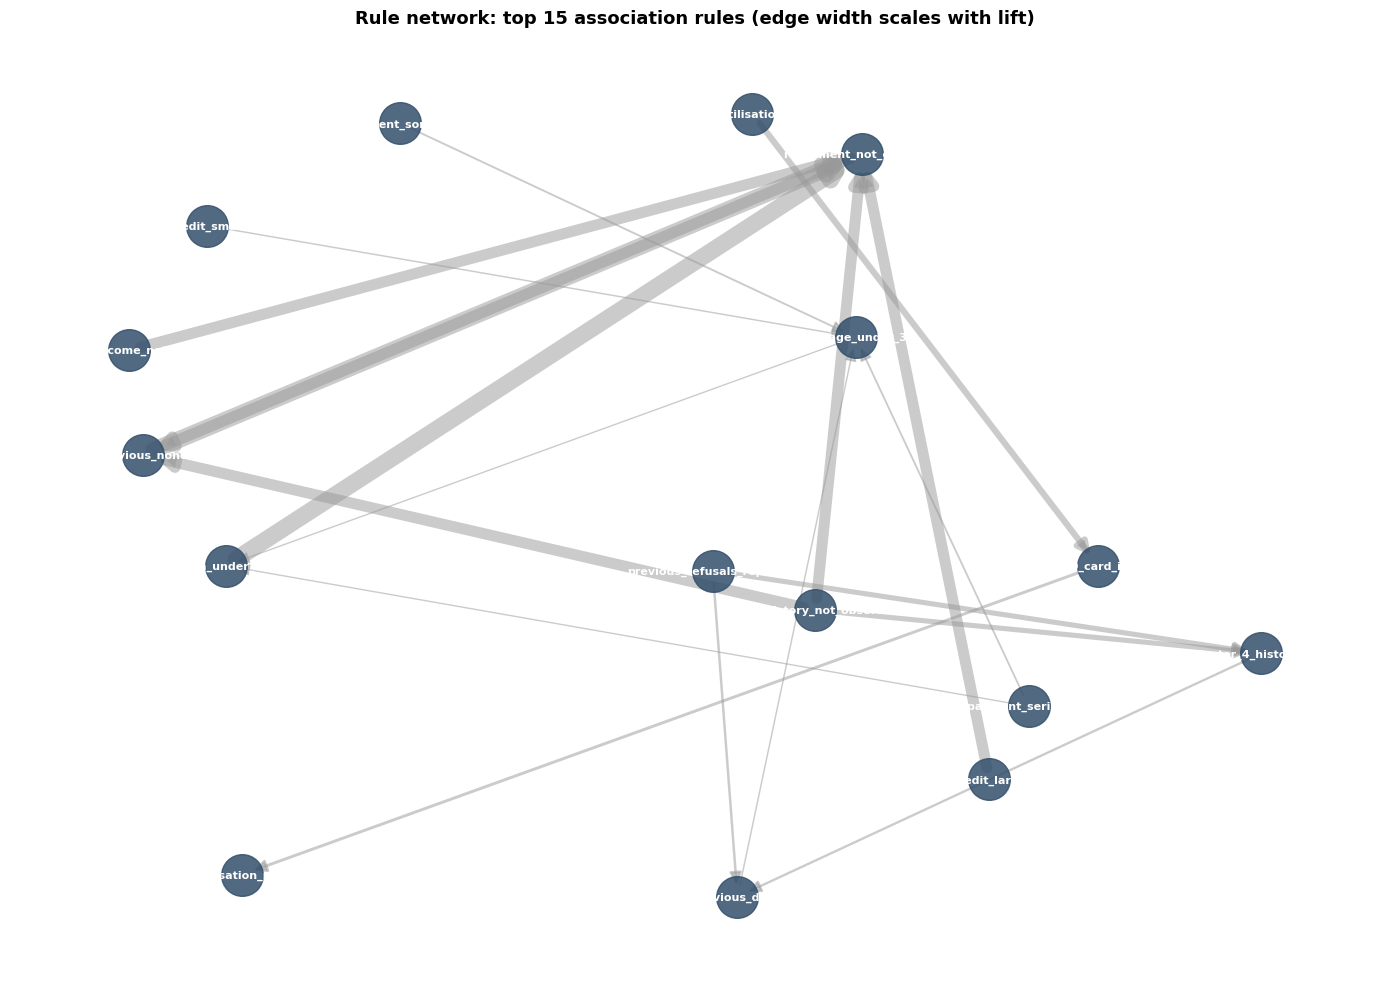

In [10]:
# Rule network: each node is a condition, an edge means the two co-occur in a final rule.
G = nx.DiGraph()
for _, r in top_rules.iterrows():
    parts = str(r['rule_str']).split(' -> ')
    ant_str, con_str = parts[0], (parts[1] if len(parts) == 2 else '')
    clean = lambda s: [i.strip().strip("'") for i in s.replace('{', '').replace('}', '').split(',') if i.strip()]
    for a in clean(ant_str):
        for c in clean(con_str):
            G.add_edge(a, c, lift=r['lift'])

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=RANDOM_SEED)
edge_widths = [G[u][v]['lift'] for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_color='#34506B', node_size=900, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w*0.7 for w in edge_widths], alpha=0.5, edge_color='#999', arrowsize=18, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)
ax.set_title('Rule network: top 15 association rules (edge width scales with lift)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_rule_network.png', dpi=150, bbox_inches='tight')
plt.show()

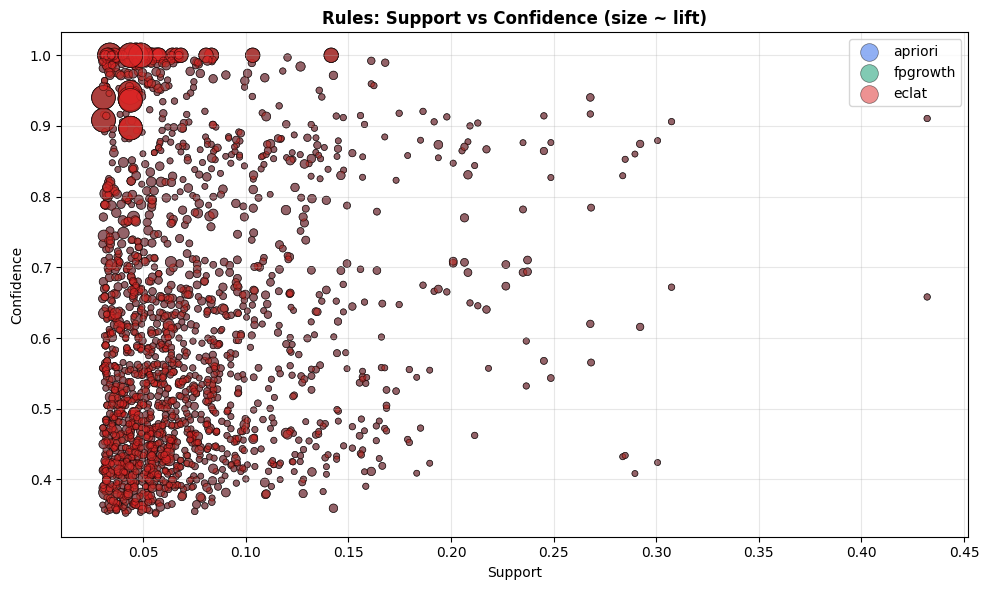

In [11]:
# Scatter support vs confidence per algoritma
fig, ax = plt.subplots(figsize=(10, 6))
algo_colors = {'apriori': '#2563EB', 'fpgrowth': '#059669', 'eclat': '#DC2626'}
for algo_name, color in algo_colors.items():
    df_a = {'apriori': rules_apriori, 'fpgrowth': rules_fp, 'eclat': rules_eclat}[algo_name]
    if len(df_a):
        ax.scatter(df_a['support'], df_a['confidence'], s=df_a['lift']*15, c=color, label=algo_name, alpha=0.5, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
ax.set_title('Rules: Support vs Confidence (size ~ lift)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_scatter_algo.png', dpi=150)
plt.show()

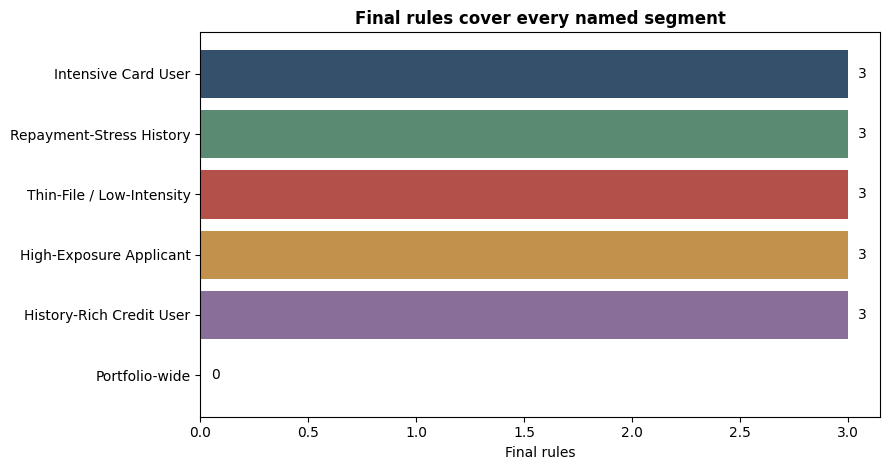

In [12]:
# Dynamic segment order from Phase 2; never hard-code numeric labels because
# K-Means cluster IDs can permute between runs.
cluster_order = [cluster_map[cid] for cid in sorted(cluster_map)] + ['global']
cluster_counts = top_rules['target_cluster'].value_counts().reindex(cluster_order, fill_value=0)
display_names = {
    cluster_map[int(r.cluster_id)]: r.nama for r in cluster_names_df.itertuples()
}
display_names['global'] = 'Portfolio-wide'
fig, ax = plt.subplots(figsize=(9, 4.8))
colors_h = ['#34506B', '#5B8A72', '#B4504A', '#C2914C', '#8A6E9A', '#6B7280']
bars = ax.barh(range(len(cluster_counts)), cluster_counts.values, color=colors_h[:len(cluster_counts)])
ax.set_yticks(range(len(cluster_counts)))
ax.set_yticklabels([display_names.get(x, x) for x in cluster_counts.index], fontsize=10)
ax.invert_yaxis(); ax.set_xlabel('Final rules')
ax.set_title('Final rules cover every named segment', fontweight='bold')
for bar, val in zip(bars, cluster_counts.values):
    ax.text(val + .05, bar.get_y() + bar.get_height()/2, f'{val}', va='center')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_cluster_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()


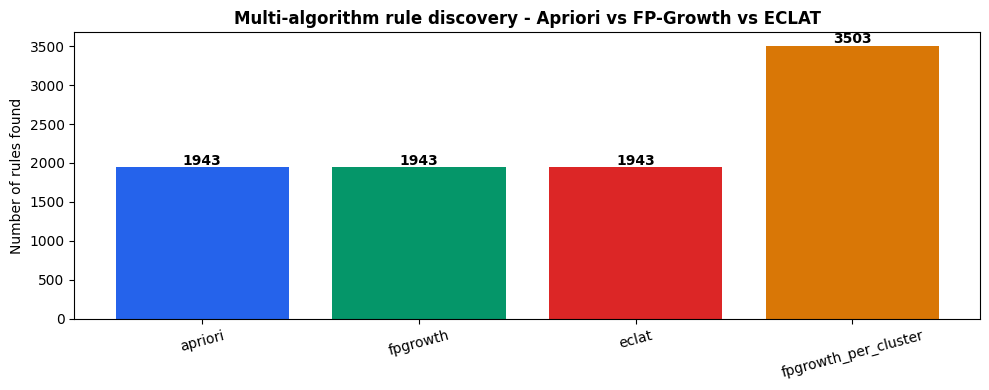

In [13]:
# Algorithm overlap bar
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(algo_df['Algoritma'], algo_df['Rules'], color=['#2563EB','#059669','#DC2626','#D97706'][:len(algo_df)])
ax.set_ylabel('Number of rules found')
ax.set_title('Multi-algorithm rule discovery - Apriori vs FP-Growth vs ECLAT', fontweight='bold')
for i, v in enumerate(algo_df['Rules']):
    ax.text(i, v + max(algo_df['Rules'])*0.01, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_algo_comparison.png', dpi=150)
plt.show()

---
Phase 3 done. The artefacts are in `results/phase3_association/`.

---
## 10. Business-readable rule view

Support says how common a pattern is, confidence says how often its
consequent follows, and lift says how much more often the combination occurs
than chance. None of these metrics is causal. The final chart therefore pairs
statistical strength with a bounded review action, and protected attributes
are absent from the rule vocabulary.


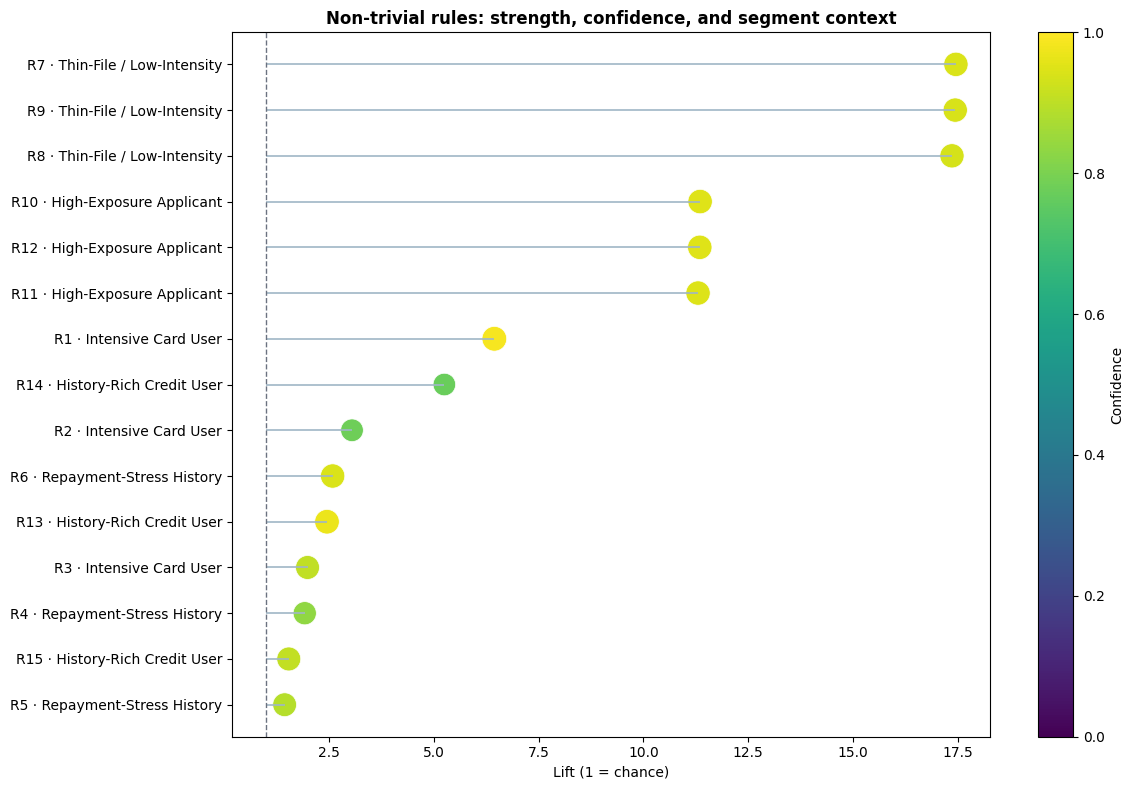

Saved 15 non-trivial, denominator-labelled rules.


In [14]:
def clean_item_text(text):
    return str(text).replace('{', '').replace('}', '').strip()

def readable_rule(rule):
    left, right = str(rule).split(' -> ', 1)
    return f'{clean_item_text(left)} → {clean_item_text(right)}'

def rule_action(rule):
    text = str(rule)
    if 'repayment_serious_late' in text or 'repayment_some_late' in text:
        return 'Review arrears recency, severity, and cure status'
    if 'burden_over_35pct' in text or 'leverage_over_6x' in text:
        return 'Verify income and run an affordability stress review'
    if 'card_utilisation_high' in text:
        return 'Review balances, payment capacity, and limit suitability'
    if any(token in text for token in [
        'credit_file_none', 'repayment_not_observed', 'card_history_not_observed',
        'previous_none', 'previous_outcome_not_observed', 'external_score_unavailable']):
        return 'Treat absence as uncertainty; verify permitted alternative evidence'
    if 'bureau_debt_high' in text or 'previous_refusals_repeated' in text:
        return 'Reconcile current obligations and whether historical concerns remain current'
    return 'Use for segment communication or standard review, not an individual decision'

display_names = {cluster_map[int(r.cluster_id)]: r.nama for r in cluster_names_df.itertuples()}
display_names['global'] = 'Portfolio-wide'
rule_view = top_rules.copy()
rule_view['short_rule'] = rule_view['rule_str'].map(readable_rule)
rule_view['Segment'] = rule_view['target_cluster'].map(display_names).fillna('Portfolio-wide')
rule_view['Context'] = rule_view['context'].map(display_names).fillna(rule_view['context'])
rule_view['review_action'] = rule_view['rule_str'].map(rule_action)
export_cols = [
    'rank', 'short_rule', 'Segment', 'Context', 'support_count', 'support',
    'confidence', 'lift', 'n_algos', 'metric_scope', 'review_action']
rule_view[export_cols].to_csv(OUT_DIR / 'rule_visual_summary.csv', index=False)

plot_rules = rule_view.sort_values('lift')
fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(plot_rules))
points = ax.scatter(plot_rules['lift'], y,
                    s=70 + plot_rules['confidence'] * 250,
                    c=plot_rules['confidence'], cmap='viridis', vmin=0, vmax=1,
                    edgecolors='white', linewidth=.5)
ax.hlines(y, 1, plot_rules['lift'], color='#9FB6C6', linewidth=1.2)
ax.axvline(1, color='#6B7280', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels([f'R{int(r)} · {s}' for r, s in zip(plot_rules['rank'], plot_rules['Segment'])])
ax.set_xlabel('Lift (1 = chance)')
ax.set_title('Non-trivial rules: strength, confidence, and segment context', fontweight='bold')
plt.colorbar(points, ax=ax, label='Confidence')
plt.tight_layout(); plt.savefig(OUT_DIR / 'plot_rule_strength.png', dpi=170, bbox_inches='tight'); plt.show()

segment_metrics = rule_view.groupby('Segment').agg(
    rules=('rank', 'count'), support_records=('support_count', 'sum'),
    mean_support=('support', 'mean'), mean_confidence=('confidence', 'mean'),
    mean_lift=('lift', 'mean')).reset_index()
segment_metrics.to_csv(OUT_DIR / 'rule_segment_summary.csv', index=False)
print(f'Saved {len(rule_view)} non-trivial, denominator-labelled rules.')
